### Python Lists VS Numpy Arrays

In [18]:
# Python lists are dynamic arrays, so it takes time to resize them during appends.
a = [i for i in range(100000)]
b = [i for i in range(100000,200000)]

c = []
import time

start = time.time()
for i in range(len(a)):
    c.append(a[i] + b[i])
print(time.time() - start)

0.02257084846496582


In [19]:
# Numpy arrays are more efficient for numerical operations.
import numpy as np

a1 = np.arange(100000)
b1 = np.arange(100000,200000)
start = time.time()
c1 = a1 + b1  # Element-wise addition
print(time.time() - start)

0.0003566741943359375


In [20]:
# memory usage comparison

# python list 
import sys
print(sys.getsizeof(a))

800984


In [21]:
# numpy array takes simalar memory as python list but it can be decresed further by changing data type
a1 = np.arange(100000,dtype=np.int8)
print(a1.nbytes)

100000


### Advanced Indexing

In [22]:
# normal indexing
a = np.arange(12).reshape(3,4)
print(a)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [23]:
# print 5
print(a[1,1])

5


In [24]:
# disply last 2 row and col
print(a[1::,2::])

[[ 6  7]
 [10 11]]


In [25]:
# fancy indexing
arr = np.arange(24).reshape(6,4)
print(arr)


[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]


In [26]:
# find 1,3,4,6th rows
print(arr[[1,3,4,5],:])

[[ 4  5  6  7]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]


In [27]:
# Boolean indexing
bool_arr = np.random.randint(1,100,24).reshape(6,4)
print(bool_arr)

[[97 92 81 24]
 [85 68 43 53]
 [93 95  2  4]
 [55 42 78 42]
 [35 26 77  5]
 [99  8 10 16]]


In [28]:
# less than 50
bool_arr[bool_arr>50]

array([97, 92, 81, 85, 68, 53, 93, 95, 55, 78, 77, 99])

In [29]:
# even numbers
bool_arr[bool_arr % 2 == 0]

array([92, 24, 68,  2,  4, 42, 78, 42, 26,  8, 10, 16])

In [30]:
# even and greater than 50
# & is boolean and operator
bool_arr[(bool_arr % 2 == 0) & (bool_arr > 50)]

array([92, 68, 78])

In [31]:
# not divisible by 7
bool_arr[~(bool_arr % 7 == 0)]

array([97, 92, 81, 24, 85, 68, 43, 53, 93, 95,  2,  4, 55, 78, 26,  5, 99,
        8, 10, 16])

### Broadcasting 

The term broadcasting describes how NumPy treats arrays with different shapes during arithmetic operations.

The smaller array is “broadcast” across the larger array so that they have compatible shapes.

#### Broadcasting Rules

**1. Make the two arrays have the same number of dimensions.**
- If the numbers of dimensions of the two arrays are different, add new dimensions with size 1 to the head of the array with the smaller dimension until both have the same number of dimensions.

**2. Make each dimension of the two arrays the same size.**
- If the sizes of each dimension of the two arrays do not match, dimensions with size 1 are stretched to the size of the other array.
- If there is a dimension whose size is not 1 in either of the two arrays, it cannot be broadcasted, and an error is raised.

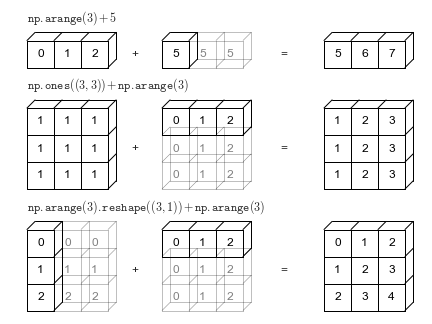

In [32]:
# same shape
a = np.arange(12).reshape(3,4)
b = np.arange(12,24).reshape(3,4)

print(a)
print(b)
print(a + b)  # element-wise addition

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]
[[12 14 16 18]
 [20 22 24 26]
 [28 30 32 34]]


In [33]:
# diff shape
a = np.arange(12).reshape(3,4)
b = np.arange(4).reshape(1,4)

print(a)
print(b)
print(a + b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[0 1 2 3]]
[[ 0  2  4  6]
 [ 4  6  8 10]
 [ 8 10 12 14]]


In [34]:
# same dimension with same size but with different shape
a = np.arange(12).reshape(3,4)
b = np.arange(12).reshape(4,3)
print(a)
print(b)

# Broadcasting will not work here and will throw error
# print(a + b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


In [35]:
a = np.arange(4).reshape(1,4)
b = np.arange(4).reshape(4,1)
print(a)
print(b)
print(a + b)  # broadcasting works here
# broadcasting: smaller array is "stretched" to match the shape of the larger array
# resulting array will have shape (4,4)


[[0 1 2 3]]
[[0]
 [1]
 [2]
 [3]]
[[0 1 2 3]
 [1 2 3 4]
 [2 3 4 5]
 [3 4 5 6]]


In [37]:
a = np.arange(16).reshape(4,4)
b = np.arange(4).reshape(2,2)

print(a)
print(b)

# print(a+b)
# broadcasting will not work here as the smaller array cannot be stretched to match larger array
# broadcasting rules will not work here because:
# 1. If the arrays do not have the same number of dimensions, the shape of the smaller-dimensional array is padded with ones on its leading (left) side.
# 2. The sizes of the dimensions are compared element-wise from the trailing (right) side. Two dimensions are compatible when
#    - they are equal, or
#    - one of them is 1     


[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
[[0 1]
 [2 3]]


### Working with Mathematical formulas and functions

### Sigmoid 

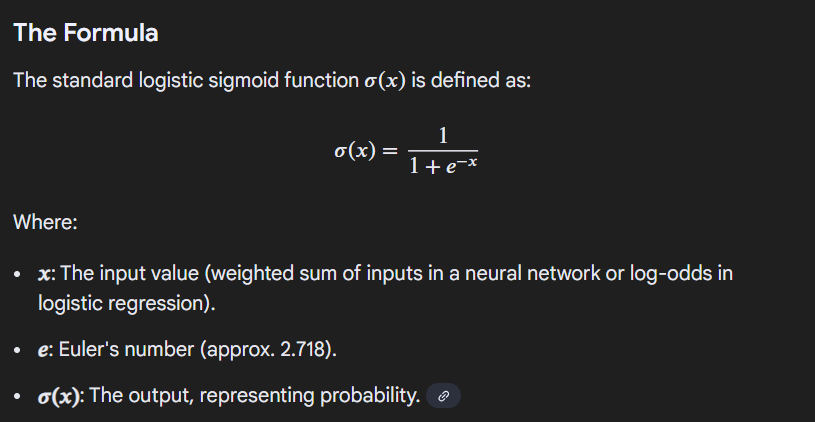

In [ ]:
# sigmoid function using numpy
def sigmoid(array):
    return 1 / (1 + np.exp(-array))

arr = np.arange(6).reshape(2,3)
sigmoid(arr)

array([[0.5       , 0.73105858, 0.88079708],
       [0.95257413, 0.98201379, 0.99330715]])

### Mean Squared Error

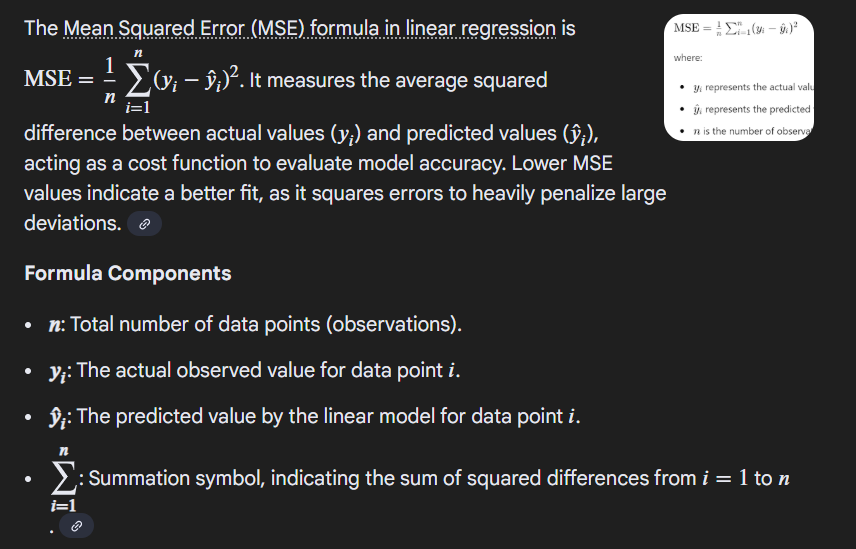

In [ ]:
# mean squared error

actual = np.random.randint(1,50,25)
predicted = np.random.randint(1,50,25)

print(actual,"\n",predicted)

[ 9  6 16 47 48 43 44 39 14 49 26 37 10 24 11 12 17 17 39  7 14  2 34 20
 23] 
 [ 9 29 12 44 42  9  9 17  3 40 42 10  8 20 22 25 24 23  2 18 14 35 30 17
 16]


In [ ]:
# mse function
def mse(actual,predicted):
    return np.mean((actual - predicted)**2)

print(mse(actual,predicted))

307.6


### Binary Cross Entropy 

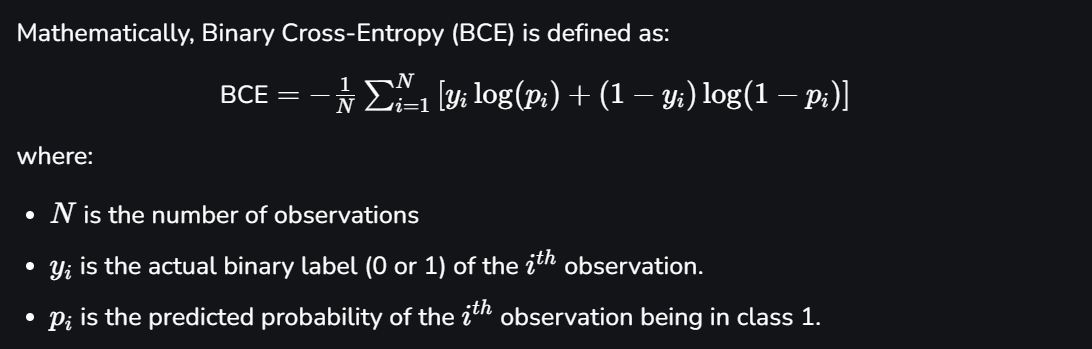

In [ ]:
print("actual data",actual)
print("predicted data",predicted)

actual data [ 9  6 16 47 48 43 44 39 14 49 26 37 10 24 11 12 17 17 39  7 14  2 34 20
 23]
predicted data [ 9 29 12 44 42  9  9 17  3 40 42 10  8 20 22 25 24 23  2 18 14 35 30 17
 16]


In [ ]:
# BCE
def bce(actual,predicted):
    predicted = np.clip(predicted, 1e-15, 1 - 1e-15)  # to avoid log(0)
    return -np.mean(actual * np.log(predicted) + (1 - actual) * np.log(1 - predicted))

print(bce(actual,predicted))

-805.4629121413894


### Working with Missing Values

- As a Data Scientist/Data Analyst there will be a need to handle the missign values
- Missing values will be registerd as nan
- we have to delete all the missing values before before hand

In [ ]:
arr = np.array([1,2,3,4,np.nan,5,6])
arr

array([ 1.,  2.,  3.,  4., nan,  5.,  6.])

In [ ]:
np.isnan(arr)

array([False, False, False, False,  True, False, False])

In [ ]:
# deleting the nan values using boolean indexing
arr[~np.isnan(arr)]

array([1., 2., 3., 4., 5., 6.])

### Plotting

In [ ]:
import matplotlib.pyplot as plt

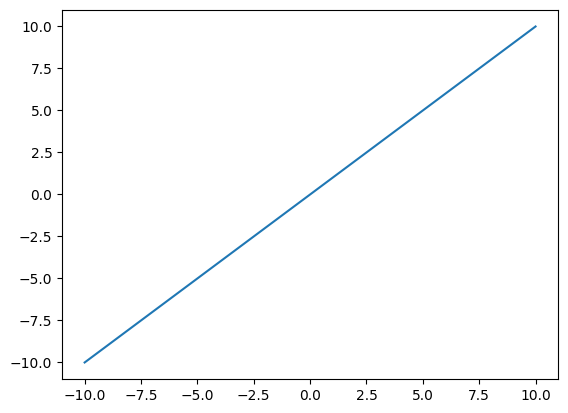

In [ ]:
# x = y
x = np.linspace(-10,10,100)
y = x

plt.plot(x,y)

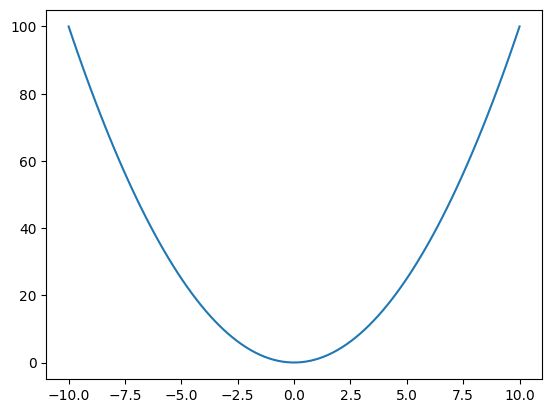

In [ ]:
# y = x^2 parabola
x = np.linspace(-10,10,100)
y = x**2
plt.plot(x,y)

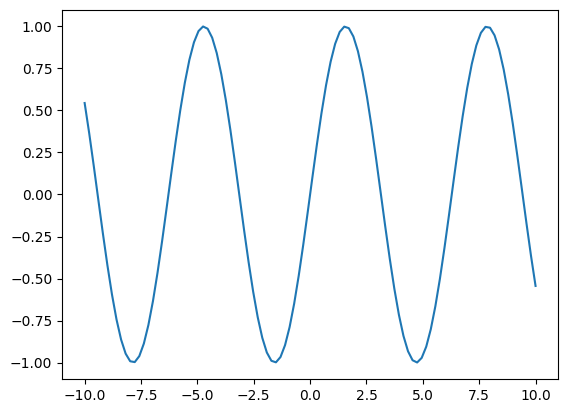

In [ ]:
# y = sin(x)

x = np.linspace(-10,10,100)
y = np.sin(x)
plt.plot(x,y)

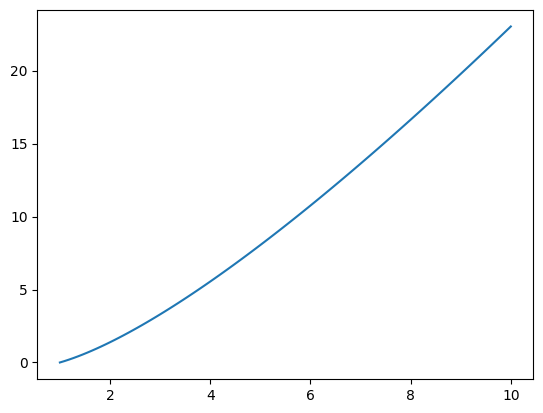

In [ ]:
# y = x * log(x)

x = np.linspace(1,10,100)
y = x * np.log(x)
plt.plot(x,y)

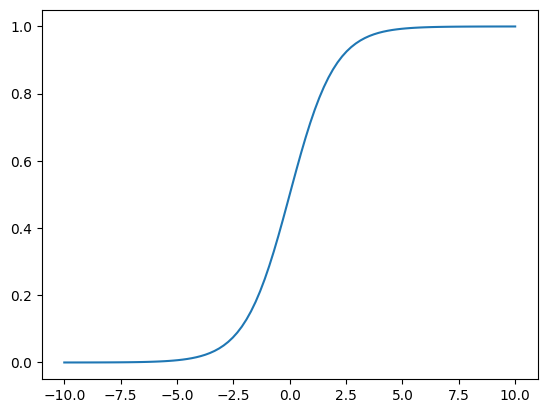

In [ ]:
# sigmoid function plot
x = np.linspace(-10,10,100)
y = 1 / (1 + np.exp(-x))

plt.plot(x,y)